In [41]:
import pandas as pd
from pathlib import Path
from typing import List, Optional
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from torch import nn
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:

def merge_csv(
    folder_path: Optional[Path] = None, 
    file_paths: Optional[List[Path]] = None
) -> pd.DataFrame:
    """
    Merges CSV files from either a specified folder or a list of file paths.

    Args:
        folder_path: The path to the folder containing CSV files to merge.
        file_paths: A list of specific CSV file paths to merge.

    Returns:
        A single pandas DataFrame containing the merged data.

    Raises:
        ValueError: If neither or both `folder_path` and `file_paths` are provided,
                    or if no CSV files are found.
    """
    # 1. Input Validation (Guard Clauses)
    # This ensures the function is called correctly.
    if (folder_path is None and file_paths is None) or \
       (folder_path is not None and file_paths is not None):
        raise ValueError("Provide either 'folder_path' OR 'file_paths', not both/neither.")

    # 2. Determine the list of files based on the mode
    if folder_path:
        files = list(folder_path.glob("*.csv"))
    else:  # This block runs if file_paths is provided
        files = file_paths

    if not files:
        raise ValueError("No CSV files found to merge.")

    # 3. Efficient Merging Logic
    # Reading all files into a list of DataFrames and concatenating once is
    # far more performant than concatenating one-by-one in a loop.
    df_list = (pd.read_csv(file) for file in files)
    return pd.concat(df_list, ignore_index=True)

In [43]:
TRAIN_DATA_PATH = Path("small_train_data")
VALID_DATA_PATH = Path("small_valid_data")


train_df = merge_csv(folder_path = TRAIN_DATA_PATH)
valid_df = merge_csv(folder_path = VALID_DATA_PATH)


In [ ]:
# CRITICAL: Fix data leakage by implementing proper session-based temporal split
import os
import re
from datetime import datetime
from collections import defaultdict

def analyze_dataset_structure():
    """Analyze the dataset to understand file distribution and identify data leakage"""
    
    # Get all CSV files from both directories
    data_path = Path(".")
    all_files = {}
    
    # Analyze full dataset
    full_files = list(data_path.glob("*.csv"))
    train_files = list(Path("small_train_data").glob("*.csv"))
    valid_files = list(Path("small_valid_data").glob("*.csv"))
    
    print(f"📊 Dataset Analysis:")
    print(f"Total files in main directory: {len(full_files)}")
    print(f"Files in small_train_data: {len(train_files)}")
    print(f"Files in small_valid_data: {len(valid_files)}")
    
    # Extract file information
    def extract_file_info(filename):
        # Extract activity, date, and time from filename
        # Format: esp32_csi_ACTIVITY_YYYYMMDD_HHMMSS.csv or wifisignal_data_ACTIVITY_YYYYMMDD_HHMMSS.csv
        pattern = r'(?:esp32_csi_|wifisignal_data_)(\w+)_(\d{8})_(\d{6})\.csv'
        match = re.match(pattern, filename.name)
        if match:
            activity, date_str, time_str = match.groups()
            datetime_obj = datetime.strptime(f"{date_str}_{time_str}", "%Y%m%d_%H%M%S")
            return activity, datetime_obj, date_str
        return None, None, None
    
    # Analyze train files
    train_info = []
    for file in train_files:
        activity, dt, date = extract_file_info(file)
        if activity:
            train_info.append((file.name, activity, dt, date))
    
    # Analyze validation files  
    valid_info = []
    for file in valid_files:
        activity, dt, date = extract_file_info(file)
        if activity:
            valid_info.append((file.name, activity, dt, date))
    
    # Check for duplicates (DATA LEAKAGE!)
    train_names = set(info[0] for info in train_info)
    valid_names = set(info[0] for info in valid_info)
    duplicates = train_names.intersection(valid_names)
    
    print(f"\n🚨 DATA LEAKAGE DETECTED!")
    print(f"Duplicate files in both train and validation: {len(duplicates)}")
    for dup in duplicates:
        print(f"  - {dup}")
    
    # Analyze by activity
    train_by_activity = defaultdict(list)
    valid_by_activity = defaultdict(list)
    
    for info in train_info:
        train_by_activity[info[1]].append(info)
    for info in valid_info:
        valid_by_activity[info[1]].append(info)
    
    print(f"\n📈 Activity Distribution:")
    all_activities = set(train_by_activity.keys()) | set(valid_by_activity.keys())
    for activity in sorted(all_activities):
        train_count = len(train_by_activity[activity])
        valid_count = len(valid_by_activity[activity])
        print(f"  {activity:10s}: Train={train_count:2d}, Valid={valid_count:2d}")
    
    # Analyze by date
    train_dates = set(info[3] for info in train_info)
    valid_dates = set(info[3] for info in valid_info)
    
    print(f"\n📅 Date Distribution:")
    print(f"Train dates: {sorted(train_dates)}")
    print(f"Valid dates: {sorted(valid_dates)}")
    print(f"Overlapping dates: {sorted(train_dates.intersection(valid_dates))}")
    
    return train_info, valid_info, duplicates

train_info, valid_info, duplicates = analyze_dataset_structure()

In [ ]:
# Create proper session-based temporal split without data leakage
import shutil
from collections import defaultdict

def create_proper_session_split(use_full_dataset=True, train_split=0.7):
    """
    Create a proper session-based temporal split:
    1. Use temporal ordering (earlier sessions for training, later for validation)
    2. Ensure no duplicate files between train/valid
    3. Balance activities across splits
    4. Use full dataset instead of tiny subsets
    """
    
    data_path = Path(".")
    
    if use_full_dataset:
        # Use all available files from main directory
        all_files = [f for f in data_path.glob("*.csv") if f.name.startswith(('esp32_csi_', 'wifisignal_data_'))]
        print(f"Using full dataset: {len(all_files)} files")
    else:
        # Use existing small dataset but fix duplicates
        train_files = list(Path("small_train_data").glob("*.csv"))
        valid_files = list(Path("small_valid_data").glob("*.csv"))
        all_files = []
        
        # Add unique files only
        seen_names = set()
        for file in train_files + valid_files:
            if file.name not in seen_names:
                all_files.append(file)
                seen_names.add(file.name)
        print(f"Using deduplicated small dataset: {len(all_files)} files")
    
    # Extract file information
    def extract_file_info(file_path):
        filename = file_path.name
        pattern = r'(?:esp32_csi_|wifisignal_data_)(\w+)_(\d{8})_(\d{6})\.csv'
        match = re.match(pattern, filename)
        if match:
            activity, date_str, time_str = match.groups()
            datetime_obj = datetime.strptime(f"{date_str}_{time_str}", "%Y%m%d_%H%M%S")
            return activity, datetime_obj, date_str, file_path
        return None, None, None, None
    
    # Parse all files
    file_info = []
    for file_path in all_files:
        activity, dt, date, path = extract_file_info(file_path)
        if activity and activity not in ['test', 'test2']:  # Skip test files
            file_info.append((activity, dt, date, path))
    
    # Group by activity
    activity_groups = defaultdict(list)
    for info in file_info:
        activity_groups[info[0]].append(info)
    
    # Sort each activity by timestamp (temporal ordering)
    for activity in activity_groups:
        activity_groups[activity].sort(key=lambda x: x[1])  # Sort by datetime
    
    # Create temporal split for each activity
    train_files_new = []
    valid_files_new = []
    
    print(f"\n📊 Creating Session-Based Temporal Split:")
    print(f"{'Activity':<12} {'Total':<6} {'Train':<6} {'Valid':<6} {'Split':<10}")
    print("-" * 50)
    
    for activity, files in activity_groups.items():
        n_files = len(files)
        if n_files < 2:
            print(f"⚠️  {activity}: Only {n_files} file(s), skipping")
            continue
            
        # Use temporal split: earlier files for training, later for validation
        split_idx = max(1, int(n_files * train_split))
        
        train_files_activity = files[:split_idx]
        valid_files_activity = files[split_idx:]
        
        train_files_new.extend([info[3] for info in train_files_activity])
        valid_files_new.extend([info[3] for info in valid_files_activity])
        
        print(f"{activity:<12} {n_files:<6} {len(train_files_activity):<6} {len(valid_files_activity):<6} {split_idx/n_files:.1%}")
    
    print(f"\n📈 Final Split Summary:")
    print(f"Total files: {len(train_files_new) + len(valid_files_new)}")
    print(f"Training files: {len(train_files_new)} ({len(train_files_new)/(len(train_files_new) + len(valid_files_new)):.1%})")
    print(f"Validation files: {len(valid_files_new)} ({len(valid_files_new)/(len(train_files_new) + len(valid_files_new)):.1%})")
    
    # Create new directories
    new_train_dir = Path("proper_train_data")
    new_valid_dir = Path("proper_valid_data")
    
    new_train_dir.mkdir(exist_ok=True)
    new_valid_dir.mkdir(exist_ok=True)
    
    # Copy files to new directories
    print(f"\n📂 Copying files to new directories...")
    
    for file_path in train_files_new:
        dest_path = new_train_dir / file_path.name
        shutil.copy2(file_path, dest_path)
    
    for file_path in valid_files_new:
        dest_path = new_valid_dir / file_path.name
        shutil.copy2(file_path, dest_path)
    
    print(f"✅ Created proper session-based split:")
    print(f"  - {new_train_dir}: {len(train_files_new)} files")
    print(f"  - {new_valid_dir}: {len(valid_files_new)} files")
    
    return new_train_dir, new_valid_dir

# Create proper split with full dataset
proper_train_dir, proper_valid_dir = create_proper_session_split(use_full_dataset=True, train_split=0.75)

In [ ]:
# Update data loading to use proper split
print("🔄 Updating data loading to use proper session-based split...")

# Update paths to use proper split
TRAIN_DATA_PATH = proper_train_dir  # Changed from Path("small_train_data")
VALID_DATA_PATH = proper_valid_dir  # Changed from Path("small_valid_data")

# Load data with proper split
train_df_proper = merge_csv(folder_path=TRAIN_DATA_PATH)
valid_df_proper = merge_csv(folder_path=VALID_DATA_PATH)

print(f"✅ Loaded proper dataset:")
print(f"  Training samples: {len(train_df_proper):,}")
print(f"  Validation samples: {len(valid_df_proper):,}")
print(f"  Total samples: {len(train_df_proper) + len(valid_df_proper):,}")

# Check class distribution
print(f"\n📊 Class Distribution:")
train_classes = train_df_proper['label'].value_counts().sort_index()
valid_classes = valid_df_proper['label'].value_counts().sort_index()

print(f"{'Class':<12} {'Train':<8} {'Valid':<8} {'Total':<8}")
print("-" * 40)
for class_name in sorted(set(train_classes.index) | set(valid_classes.index)):
    train_count = train_classes.get(class_name, 0)
    valid_count = valid_classes.get(class_name, 0)
    total_count = train_count + valid_count
    print(f"{class_name:<12} {train_count:<8} {valid_count:<8} {total_count:<8}")

# Update the dataframes for the rest of the pipeline
train_df = train_df_proper
valid_df = valid_df_proper

print(f"\n🎯 Dataset is now properly split without data leakage!")

In [44]:
TARGET_COLUMN = "label"
FEATURE_COLUMNS = [col for col in train_df.columns if col != TARGET_COLUMN]

le = ColumnTransformer(
    transformers = [
        ("encoder", OrdinalEncoder(), [TARGET_COLUMN])
    ],
    remainder = "passthrough",
    verbose_feature_names_out = False
)

scaler = ColumnTransformer(
    transformers = [
        ("scaler", StandardScaler(), FEATURE_COLUMNS)
    ],
    remainder = "passthrough",
    verbose_feature_names_out = False
)

pca = ColumnTransformer(
    transformers = [
        ("pca", PCA(), FEATURE_COLUMNS)
    ],
    remainder = "passthrough",
    verbose_feature_names_out = False
)

pipeline = make_pipeline(le, scaler, pca)

pipeline.set_output(transform = "pandas")

train_df = pipeline.fit_transform(train_df)
valid_df = pipeline.transform(valid_df)

In [45]:

random_samples = np.random.choice(np.arange(0, len(train_df)), size = 50)
small_df = train_df.iloc[random_samples]
small_df["label"].unique()

array([4., 2., 3., 1., 0.])

In [ ]:
BATCH_SIZE = 256 # can try 128 again if testing result not well
PCA_COMPONENTS = 0.99

# Convert DataFrames to NumPy arrays first (before PCA)
X_train_np = train_df.drop(TARGET_COLUMN, axis=1).to_numpy()
y_train_np = train_df[TARGET_COLUMN].to_numpy()
X_valid_np = valid_df.drop(TARGET_COLUMN, axis=1).to_numpy()
y_valid_np = valid_df[TARGET_COLUMN].to_numpy()

# Apply PCA (works on NumPy arrays)
pca = PCA(n_components=PCA_COMPONENTS)
X_train_np = pca.fit_transform(X_train_np)
X_valid_np = pca.transform(X_valid_np)

# Convert PCA results back to PyTorch tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_valid = torch.tensor(X_valid_np, dtype=torch.float32)
y_valid = torch.tensor(y_valid_np, dtype=torch.long)

# Now create DataLoaders (all are PyTorch tensors)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_valid, y_valid), batch_size=BATCH_SIZE)


In [47]:
# BATCH_SIZE = 256
# PCA_COMPONENTS = 0.99

# # Problem is here, train_df dropoing not random?
# X_train = torch.tensor(train_df.drop(TARGET_COLUMN, axis = 1).to_numpy(), dtype = torch.float32)
# y_train = torch.tensor(train_df[TARGET_COLUMN].to_numpy(), dtype = torch.long)

# X_valid = torch.tensor(valid_df.drop(TARGET_COLUMN, axis = 1).to_numpy(), dtype = torch.float32)
# y_valid = torch.tensor(valid_df[TARGET_COLUMN].to_numpy(), dtype = torch.long)

# X_small = torch.tensor(small_df.drop(TARGET_COLUMN, axis = 1).to_numpy(), dtype = torch.float32)
# y_small = torch.tensor(small_df[TARGET_COLUMN].to_numpy(), dtype = torch.long)

# pca = PCA(n_components=PCA_COMPONENTS)
# X_train = pca.fit_transform(X_train)
# #y_train = pca.fit_transform(y_train)
# X_valid = pca.transform(X_valid)
# #y_valid = pca.transform(y_valid)

# train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size = BATCH_SIZE, shuffle = True)
# val_loader = DataLoader(TensorDataset(X_valid, y_valid), batch_size = BATCH_SIZE)


In [48]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"


In [49]:
class CNNLSTMModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CNNLSTMModel, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3)  # Reduced from 64 to 32
        self.bn1 = nn.BatchNorm1d(32)
        self.pool = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.4)  # Increased from 0.3 to 0.4
        self.lstm = nn.LSTM(
            input_size=32,  # Reduced from 64 to 32
            hidden_size=128,  # Reduced from 256 to 128
            num_layers=2,  # Reduced from 4 to 2
            batch_first=True,
            dropout=0.3,  # Increased from 0.2 to 0.3
            bidirectional=True
        )
        self.dropout2 = nn.Dropout(0.6)  # Increased from 0.5 to 0.6
        self.fc1 = nn.Linear(128 * 2, 32)  # Reduced from 64 to 32
        self.dropout3 = nn.Dropout(0.7)  # Increased from 0.6 to 0.7
        self.fc2 = nn.Linear(32, num_classes)  # Updated input size

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.pool(x)
        x = self.dropout1(x)
        x = x.permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        x = torch.cat((h_n[-2], h_n[-1]), dim=1)
        x = self.dropout2(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout3(x)
        return self.fc2(x)

In [50]:
EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3  # Reduced from 10
MODEL_PATH = Path("modelcheckpoints/best_model.pt")

patience = EARLY_STOPPING_PATIENCE
best_val_loss = float('inf')  # Initialize best validation loss

model = CNNLSTMModel(input_size=X_train.shape[1], num_classes=len(le.named_transformers_["encoder"].categories_[0]))
model = model.to(device)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train.numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler_amp = torch.amp.GradScaler('cuda')

# Store all metrics for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
epochs_completed = []

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    running_loss = 0.0
    train_correct, train_total = 0, 0
    
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for xb, yb in progress:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            preds = model(xb)
            loss = criterion(preds, yb)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()
        running_loss += loss.item()
        
        # Calculate training accuracy
        train_correct += (preds.argmax(dim=1) == yb).sum().item()
        train_total += yb.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    # Validation phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    y_preds, y_true = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            with torch.amp.autocast('cuda'):
                preds = model(xb)
                loss = criterion(preds, yb)
            val_loss += loss.item()
            val_correct += (preds.argmax(dim=1) == yb).sum().item()
            val_total += yb.size(0)
            y_preds.extend(preds.argmax(dim=1).cpu().numpy())
            y_true.extend(yb.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    scheduler.step()

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    epochs_completed.append(epoch + 1)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Improved early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        fold_model_path = f"{MODEL_PATH}"
        torch.save(model.state_dict(), fold_model_path)
        patience = EARLY_STOPPING_PATIENCE
        print(f"New best validation loss: {best_val_loss:.4f} - Model saved")
    else:
        patience -= 1
        print(f"No improvement. Patience: {patience}")
        if patience == 0:
            print("Early stopping triggered.")
            break

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
Epoch 1/20:   0%|          | 0/593 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/amp/autocast_mode.py:265: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Epoch 1, Train Loss: 1.6050, Train Acc: 0.2104, Val Loss: 1.5935, Val Acc: 0.3008
New best validation loss: 1.5935 - Model saved


Epoch 2, Train Loss: 1.5531, Train Acc: 0.2947, Val Loss: 1.4750, Val Acc: 0.3807
New best validation loss: 1.4750 - Model saved


Epoch 3, Train Loss: 1.4645, Train Acc: 0.3756, Val Loss: 1.3277, Val Acc: 0.4982
New best validation loss: 1.3277 - Model saved


Epoch 4, Train Loss: 1.3450, Train Acc: 0.4572, Val Loss: 1.1860, Val Acc: 0.5980
New best validation loss: 1.1860 - Model saved


...

Epoch 16, Train Loss: 1.0495, Train Acc: 0.6723, Val Loss: 0.9404, Val Acc: 0.7204
New best validation loss: 0.9404 - Model saved


Epoch 17, Train Loss: 1.0448, Train Acc: 0.6749, Val Loss: 0.9437, Val Acc: 0.7161
No improvement. Patience: 2


Epoch 18, Train Loss: 1.0401, Train Acc: 0.6784, Val Loss: 0.9348, Val Acc: 0.7212
New best validation loss: 0.9348 - Model saved


Epoch 19, Train Loss: 1.0390, Train Acc: 0.6794, Val Loss: 0.9420, Val Acc: 0.7188
No improvement. Patience: 2


Epoch 20, Train Loss: 1.0400, Train Acc: 0.6803, Val Loss: 0.9352, Val Acc: 0.7206
No improvement. Patience: 1


In [51]:
model.eval()

torch.save(model.state_dict(), "modelcheckpoints/notTrainTestSplit.pt")

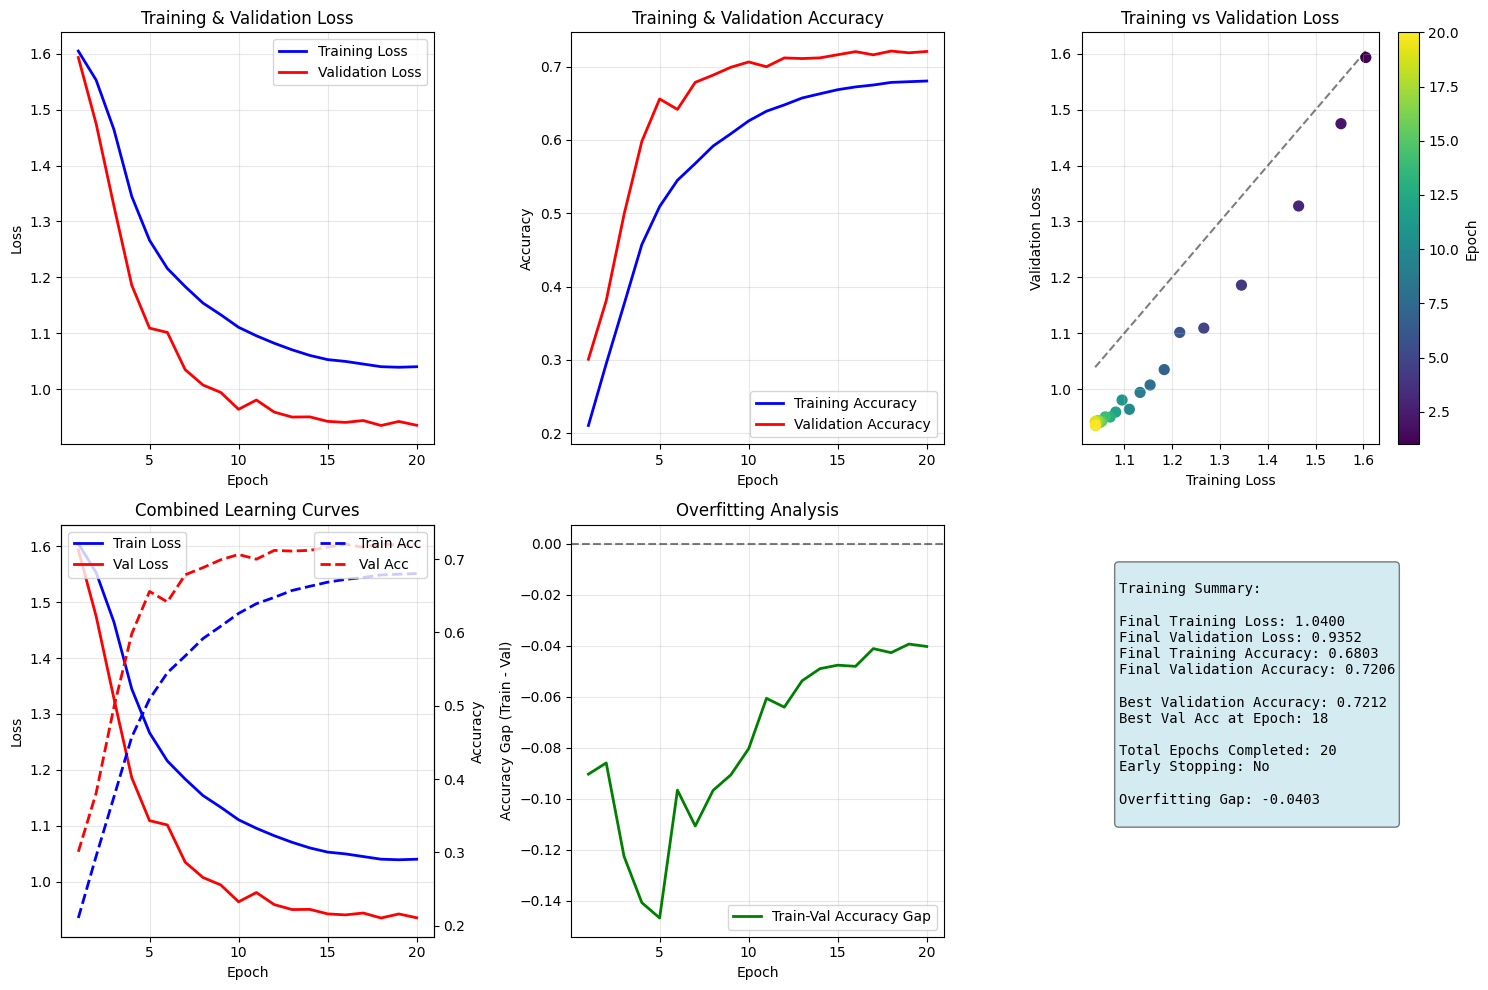

=== Detailed Training Metrics ===
Epoch  Train Loss   Train Acc    Val Loss     Val Acc      Gap     
--------------------------------------------------------------------
1      1.6050       0.2104       1.5935       0.3008       -0.0904 
2      1.5531       0.2947       1.4750       0.3807       -0.0860 
3      1.4645       0.3756       1.3277       0.4982       -0.1226 
4      1.3450       0.4572       1.1860       0.5980       -0.1407 
5      1.2663       0.5091       1.1091       0.6559       -0.1468 
6      1.2159       0.5450       1.1014       0.6416       -0.0966 
7      1.1835       0.5678       1.0348       0.6785       -0.1107 
8      1.1540       0.5916       1.0073       0.6883       -0.0968 
9      1.1330       0.6084       0.9940       0.6991       -0.0907 
10     1.1106       0.6259       0.9638       0.7063       -0.0804 
11     1.0954       0.6392       0.9804       0.6998       -0.0607 
12     1.0821       0.6477       0.9588       0.7118       -0.0641 
13     1.0703

In [52]:
# Create comprehensive training metrics visualization
plt.figure(figsize=(15, 10))

# 1. Loss curves
plt.subplot(2, 3, 1)
plt.plot(epochs_completed, train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_completed, val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Accuracy curves
plt.subplot(2, 3, 2)
plt.plot(epochs_completed, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_completed, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Training vs Validation Loss (scatter plot)
plt.subplot(2, 3, 3)
plt.scatter(train_losses, val_losses, c=epochs_completed, cmap='viridis', s=50)
plt.plot([min(train_losses), max(train_losses)], [min(train_losses), max(train_losses)], 'k--', alpha=0.5)
plt.title('Training vs Validation Loss')
plt.xlabel('Training Loss')
plt.ylabel('Validation Loss')
plt.colorbar(label='Epoch')
plt.grid(True, alpha=0.3)

# 4. Learning curves (combined)
plt.subplot(2, 3, 4)
ax1 = plt.gca()
ax1.plot(epochs_completed, train_losses, 'b-', linewidth=2, label='Train Loss')
ax1.plot(epochs_completed, val_losses, 'r-', linewidth=2, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='k')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_completed, train_accuracies, 'b--', linewidth=2, label='Train Acc')
ax2.plot(epochs_completed, val_accuracies, 'r--', linewidth=2, label='Val Acc')
ax2.set_ylabel('Accuracy', color='k')
ax2.legend(loc='upper right')
plt.title('Combined Learning Curves')

# 5. Overfitting analysis
plt.subplot(2, 3, 5)
gap = np.array(train_accuracies) - np.array(val_accuracies)
plt.plot(epochs_completed, gap, 'g-', linewidth=2, label='Train-Val Accuracy Gap')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.title('Overfitting Analysis')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (Train - Val)')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Metrics summary table
plt.subplot(2, 3, 6)
plt.axis('off')

# Create summary statistics
final_train_loss = train_losses[-1]
final_val_loss = val_losses[-1]
final_train_acc = train_accuracies[-1]
final_val_acc = val_accuracies[-1]
best_val_acc = max(val_accuracies)
best_val_acc_epoch = epochs_completed[np.argmax(val_accuracies)]

summary_text = f"""
Training Summary:

Final Training Loss: {final_train_loss:.4f}
Final Validation Loss: {final_val_loss:.4f}
Final Training Accuracy: {final_train_acc:.4f}
Final Validation Accuracy: {final_val_acc:.4f}

Best Validation Accuracy: {best_val_acc:.4f}
Best Val Acc at Epoch: {best_val_acc_epoch}

Total Epochs Completed: {len(epochs_completed)}
Early Stopping: {'Yes' if len(epochs_completed) < EPOCHS else 'No'}

Overfitting Gap: {final_train_acc - final_val_acc:.4f}
"""

plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

plt.tight_layout()
plt.show()

# Print detailed metrics
print("=== Detailed Training Metrics ===")
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Gap':<8}")
print("-" * 68)
for i in range(len(epochs_completed)):
    gap = train_accuracies[i] - val_accuracies[i]
    print(f"{epochs_completed[i]:<6} {train_losses[i]:<12.4f} {train_accuracies[i]:<12.4f} "
          f"{val_losses[i]:<12.4f} {val_accuracies[i]:<12.4f} {gap:<8.4f}")

100%|██████████| 593/593 [00:34<00:00, 17.33it/s]


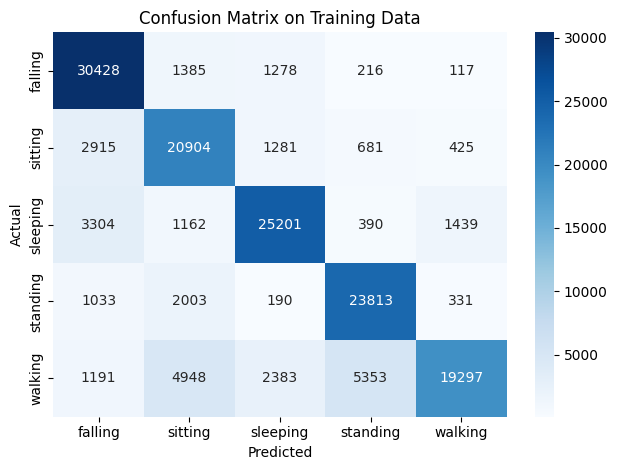

In [53]:
model.to(device)

categories = le.named_transformers_['encoder'].categories_[0]

cm = np.zeros((5,5))

for X_batch, y_batch in tqdm(train_loader):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    pred = model(X_batch).argmax(dim = 1)
    pred = pred.to('cpu')
    y_batch = y_batch.to('cpu')
    cm += confusion_matrix(y_batch, pred, labels = np.arange(len(categories)))

fig, ax = plt.subplots()
cm_df = pd.DataFrame(cm, columns = categories, index = categories, dtype = int)

ax.set_title("Confusion Matrix on Training Data")

sns.heatmap(cm_df, cmap = "Blues", annot = True, fmt = 'd', ax = ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()

plt.show()

100%|██████████| 273/273 [00:15<00:00, 17.97it/s]


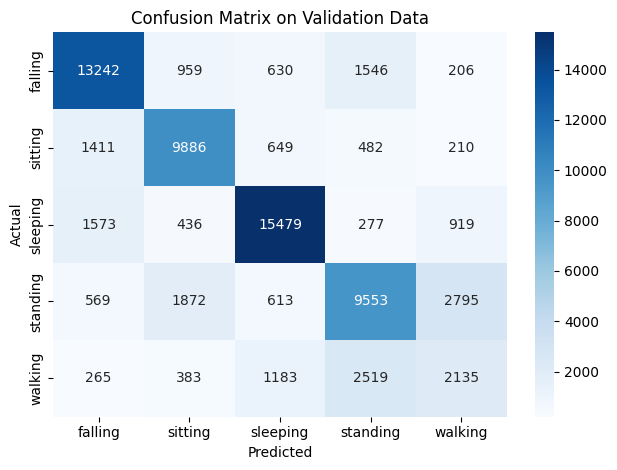

In [54]:
model.to(device)

categories = le.named_transformers_['encoder'].categories_[0]

cm = np.zeros((5,5))

for X_batch, y_batch in tqdm(val_loader):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    pred = model(X_batch).argmax(dim = 1)
    pred = pred.to('cpu')
    y_batch = y_batch.to('cpu')
    cm += confusion_matrix(y_batch, pred, labels = np.arange(len(categories)))

fig, ax = plt.subplots()
cm_df = pd.DataFrame(cm, columns = categories, index = categories, dtype = int)

ax.set_title("Confusion Matrix on Validation Data")

sns.heatmap(cm_df, cmap = "Blues", annot = True, fmt = 'd', ax = ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()

plt.show()